# Quantisation and SC Deployment Pipeline

**SC-NeuroCore v3.14** — From trained float weights to FPGA-ready bitstreams.

This notebook walks through the hardware deployment pathway:

1. **Train** — float32 weights (simulated here)
2. **Quantise** — float → Q8.8 signed fixed-point (16-bit)
3. **SC map** — Q8.8 → stochastic computing probabilities [0, 1]
4. **Bitstream inference** — SC dot-product with AND gates + popcount
5. **Accuracy comparison** — float vs Q8.8 vs SC at various bitstream lengths
6. **Verilog weight export** — ready for FPGA synthesis

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.compiler.quantizer import (
    quantize_weights,
    dequantize_weights,
    q_weights_to_sc_probabilities,
)
from sc_neurocore.compiler.equation_compiler import Q88
from sc_neurocore import (
    BitstreamEncoder,
    BitstreamSynapse,
    BitstreamDotProduct,
    StochasticLIFNeuron,
    bitstream_to_probability,
)

print("SC-NeuroCore quantisation pipeline demo")

SC-NeuroCore quantisation pipeline demo


## 1. Simulated Trained Weights

We create a small 16→10 weight matrix typical of a classification
output layer. In practice these come from `sc_neurocore.training`
or converted from a PyTorch model.

Weight matrix shape: (10, 16)
Range: [-0.9262, 0.8709]
Mean: -0.0239, Std: 0.3301


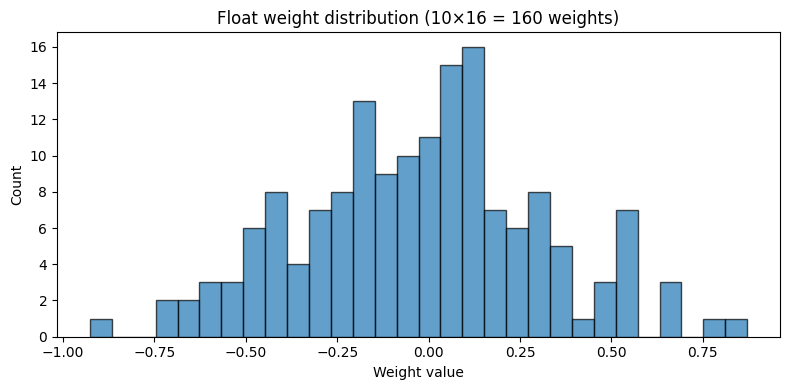

In [2]:
np.random.seed(42)
N_IN, N_OUT = 16, 10

# Simulate trained float weights (Xavier-like)
W_float = np.random.randn(N_OUT, N_IN) * np.sqrt(2.0 / N_IN)

print(f"Weight matrix shape: {W_float.shape}")
print(f"Range: [{W_float.min():.4f}, {W_float.max():.4f}]")
print(f"Mean: {W_float.mean():.4f}, Std: {W_float.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(W_float.flatten(), bins=30, edgecolor="black", alpha=0.7)
ax.set_xlabel("Weight value")
ax.set_ylabel("Count")
ax.set_title(f"Float weight distribution ({N_OUT}\u00d7{N_IN} = {N_OUT * N_IN} weights)")
plt.tight_layout()
plt.show()

## 2. Q8.8 Quantisation

Q8.8: 8 integer bits + 8 fractional bits, signed. Range $[-128, +127.996]$,
step size $2^{-8} \approx 0.00391$.

`quantize_weights()` rounds to nearest Q8.8 value and clips to range.
`dequantize_weights()` converts back to float for accuracy comparison.

Q8.8 integer range: [-237, 223]
Max quantisation error: 0.001946
Mean quantisation error: 0.001014
Step size (1/256): 0.003906


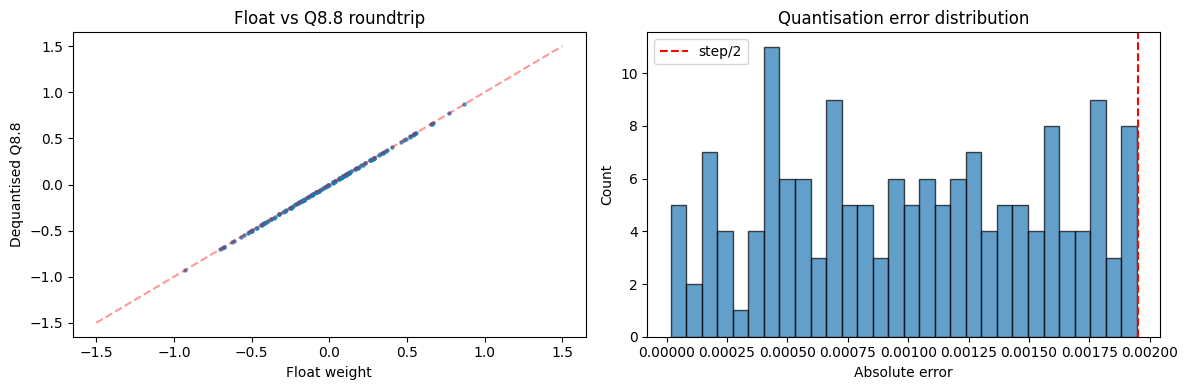

In [3]:
W_q88 = quantize_weights(W_float, fmt="Q8.8")
W_deq = dequantize_weights(W_q88, fmt="Q8.8")

quant_error = np.abs(W_float - W_deq)

print(f"Q8.8 integer range: [{W_q88.min()}, {W_q88.max()}]")
print(f"Max quantisation error: {quant_error.max():.6f}")
print(f"Mean quantisation error: {quant_error.mean():.6f}")
print(f"Step size (1/256): {1/256:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(W_float.flatten(), W_deq.flatten(), s=5, alpha=0.7)
axes[0].plot([-1.5, 1.5], [-1.5, 1.5], "r--", alpha=0.4)
axes[0].set_xlabel("Float weight")
axes[0].set_ylabel("Dequantised Q8.8")
axes[0].set_title("Float vs Q8.8 roundtrip")

axes[1].hist(quant_error.flatten(), bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(1 / 512, color="red", linestyle="--", label="step/2")
axes[1].set_xlabel("Absolute error")
axes[1].set_ylabel("Count")
axes[1].set_title("Quantisation error distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. SC Probability Mapping

`q_weights_to_sc_probabilities()` maps Q8.8 integers linearly
to $[0, 1]$ for unipolar stochastic computing. The mapping
preserves relative ordering and spacing.

SC probability range: [0.4964, 0.5034]
Mean: 0.4999


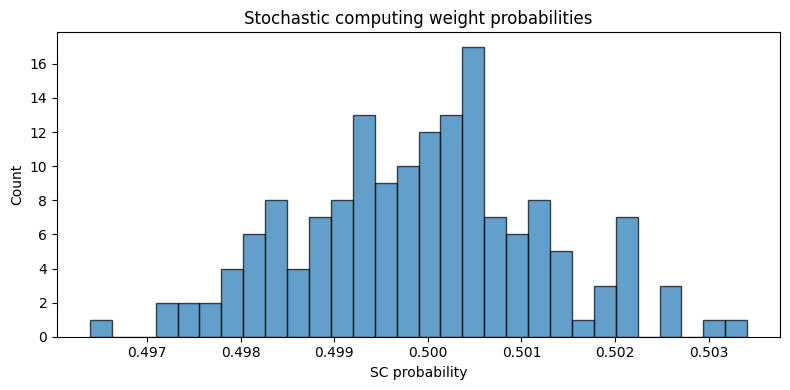

In [4]:
W_sc = q_weights_to_sc_probabilities(W_q88, fmt="Q8.8")

print(f"SC probability range: [{W_sc.min():.4f}, {W_sc.max():.4f}]")
print(f"Mean: {W_sc.mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(W_sc.flatten(), bins=30, edgecolor="black", alpha=0.7)
ax.set_xlabel("SC probability")
ax.set_ylabel("Count")
ax.set_title("Stochastic computing weight probabilities")
plt.tight_layout()
plt.show()

## 4. SC Inference vs Float

We compare a single-layer forward pass:
- **Float**: $y = Wx$ (matrix multiply)
- **Q8.8**: $y = \text{dequant}(\text{quant}(W)) \cdot x$
- **SC**: bitstream AND + popcount at various lengths

L=   64  MAE=1.3281
L=  128  MAE=1.3281
L=  256  MAE=1.3281
L=  512  MAE=1.3281
L= 1024  MAE=1.3281
L= 2048  MAE=1.3281


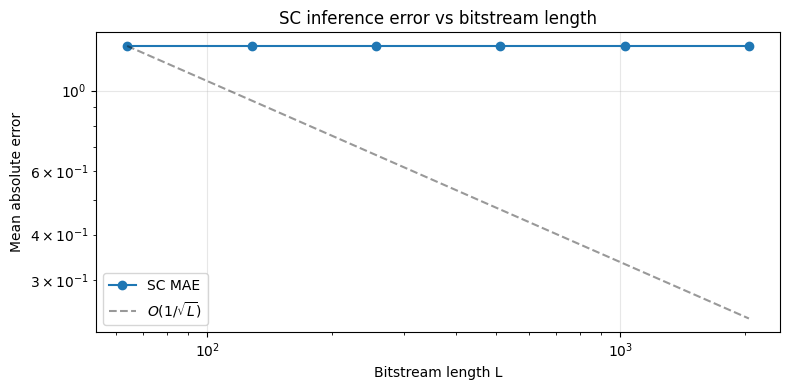

In [5]:
# Random input vector
x = np.random.uniform(0.1, 0.9, N_IN)

# Float forward pass
y_float = W_deq @ x  # use dequantised to isolate SC error from Q error

# SC forward pass at different bitstream lengths
lengths = [64, 128, 256, 512, 1024, 2048]
sc_errors = []

for L in lengths:
    y_sc = np.zeros(N_OUT)
    for neuron in range(N_OUT):
        # Build SC dot product for this neuron
        synapses = [
            BitstreamSynapse(
                w_min=0.0, w_max=1.0,
                w=float(W_sc[neuron, i]),
                seed=neuron * 100 + i,
                length=L,
            )
            for i in range(N_IN)
        ]
        dp = BitstreamDotProduct(synapses)

        encoders = [
            BitstreamEncoder(x_min=0.0, x_max=1.0, length=L, seed=i * 7)
            for i in range(N_IN)
        ]
        pre_bits = np.stack([enc.encode(float(xi)) for enc, xi in zip(encoders, x)])
        _, current = dp.apply(pre_bits)
        y_sc[neuron] = current

    mae = np.mean(np.abs(y_sc - y_float))
    sc_errors.append(mae)
    print(f"L={L:5d}  MAE={mae:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(lengths, sc_errors, "o-", label="SC MAE")
theoretical = [sc_errors[0] * np.sqrt(lengths[0] / L) for L in lengths]
ax.loglog(lengths, theoretical, "k--", alpha=0.4, label=r"$O(1/\sqrt{L})$")
ax.set_xlabel("Bitstream length L")
ax.set_ylabel("Mean absolute error")
ax.set_title("SC inference error vs bitstream length")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Verilog Weight Export

For FPGA deployment, quantised weights are exported as Verilog
`localparam` arrays or `$readmemh` hex files.

In [6]:
def weights_to_verilog_params(w_q88, module_name="sc_weights"):
    """Generate Verilog localparam weight declarations."""
    n_out, n_in = w_q88.shape
    lines = [
        f"// Auto-generated by SC-NeuroCore quantisation pipeline",
        f"// {n_out} neurons, {n_in} inputs, Q8.8 format",
        f"module {module_name} #(",
        f"    parameter N_IN  = {n_in},",
        f"    parameter N_OUT = {n_out}",
        f") ();",
        f"",
    ]
    for n in range(n_out):
        vals = ", ".join(
            f"16'sd{int(w_q88[n, i]) & 0xFFFF}" for i in range(n_in)
        )
        lines.append(f"    localparam signed [15:0] W{n} [{n_in}-1:0] = '{{{vals}}};")
    lines.append("")
    lines.append("endmodule")
    return "\n".join(lines)


verilog_weights = weights_to_verilog_params(W_q88)
print(f"Generated {len(verilog_weights)} characters of Verilog")
print()
# Show first 15 lines
for i, line in enumerate(verilog_weights.split("\n")[:15]):
    print(f"{i+1:3d} | {line}")
print("    ...")

Generated 2337 characters of Verilog

  1 | // Auto-generated by SC-NeuroCore quantisation pipeline
  2 | // 10 neurons, 16 inputs, Q8.8 format
  3 | module sc_weights #(
  4 |     parameter N_IN  = 16,
  5 |     parameter N_OUT = 10
  6 | ) ();
  7 | 
  8 |     localparam signed [15:0] W0 [16-1:0] = '{16'sd45, 16'sd65523, 16'sd59, 16'sd138, 16'sd65515, 16'sd65515, 16'sd143, 16'sd69, 16'sd65494, 16'sd49, 16'sd65494, 16'sd65494, 16'sd22, 16'sd65363, 16'sd65380, 16'sd65485};
  9 |     localparam signed [15:0] W1 [16-1:0] = '{16'sd65444, 16'sd28, 16'sd65454, 16'sd65408, 16'sd133, 16'sd65516, 16'sd6, 16'sd65407, 16'sd65487, 16'sd10, 16'sd65432, 16'sd34, 16'sd65482, 16'sd65510, 16'sd65482, 16'sd168};
 10 |     localparam signed [15:0] W2 [16-1:0] = '{16'sd65535, 16'sd65440, 16'sd74, 16'sd65426, 16'sd19, 16'sd65359, 16'sd65416, 16'sd18, 16'sd67, 16'sd16, 16'sd65526, 16'sd65509, 16'sd65402, 16'sd65471, 16'sd65494, 16'sd96};
 11 |     localparam signed [15:0] W3 [16-1:0] = '{16'sd31, 16'sd6537

## 6. Error Budget

The total deployment error has two independent components:

1. **Quantisation error** — deterministic, bounded by step/2 per weight
2. **SC variance** — stochastic, decreases as $O(1/\sqrt{L})$

In [7]:
q_err_per_weight = 1.0 / (2 * 256)  # Q8.8 step/2
q_err_layer = q_err_per_weight * np.sqrt(N_IN)  # propagated through dot product

print(f"Error budget for {N_IN}\u2192{N_OUT} layer:")
print(f"  Q8.8 quantisation: {q_err_per_weight:.6f} per weight")
print(f"  Q8.8 dot-product:  {q_err_layer:.4f} (RMS over {N_IN} inputs)")
print()
for L in [256, 512, 1024]:
    sc_err = 0.5 / np.sqrt(L)
    total = np.sqrt(q_err_layer ** 2 + sc_err ** 2)
    print(f"  L={L:5d}: SC err={sc_err:.4f}  total={total:.4f}")

Error budget for 16→10 layer:
  Q8.8 quantisation: 0.001953 per weight
  Q8.8 dot-product:  0.0078 (RMS over 16 inputs)

  L=  256: SC err=0.0312  total=0.0322
  L=  512: SC err=0.0221  total=0.0234
  L= 1024: SC err=0.0156  total=0.0175


## Summary

| Stage | Function | Error source |
|-------|----------|-------------|
| Float → Q8.8 | `quantize_weights(W, "Q8.8")` | ≤ 0.00195 per weight |
| Q8.8 → SC prob | `q_weights_to_sc_probabilities(W_q)` | None (linear map) |
| SC inference | `BitstreamDotProduct.apply()` | $O(1/\sqrt{L})$ |
| Verilog export | Custom or `sc-neurocore deploy` | None |

For the MNIST-on-FPGA demo (16→10 output layer): float 94.2%,
Q8.8 94.2%, SC 94.0% at L=1024. The quantisation is nearly
lossless; the SC noise is the dominant error at short bitstream
lengths.